# Введение в RL и пакет Gymnasium

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* https://gymnasium.farama.org/
* https://pypi.org/project/ufal.pybox2d/
* https://gymnasium.farama.org/tutorials/gymnasium_basics/environment_creation/
* https://gymnasium.farama.org/api/spaces/fundamental/
* https://gymnasium.farama.org/environments/toy_text/blackjack/

## Задачи для совместного разбора

1\. Рассмотрите пример создания окружения `gymnasium` и основные этапы взаимодействия с этим окружением.

<img src="https://gymnasium.farama.org/_images/AE_loop.png" width="300"/>

In [1]:
# Создание окружения
import gymnasium as gym

env = gym.make("CartPole-v1")
print(f"Action space: {env.action_space}")  # Discrete(2)
print(f"Observation space: {env.observation_space}")  # Box(4,)

Action space: Discrete(2)
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


In [2]:
# Определение нейросети DQN
import torch
import torch.nn as nn

class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

In [3]:
# Агент DQN
from collections import deque
import torch.optim as optim
import random

class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)  # память воспроизведения
        self.gamma = 0.99  # коэффициент дисконтирования
        self.epsilon = 1.0  # начальная вероятность случайного действия
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.batch_size = 64

        # Основная и целевая сети
        self.model = DQN(state_size, action_size)
        self.target_model = DQN(state_size, action_size)
        self.update_target_model()

        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.loss_fn = nn.MSELoss()

    def update_target_model(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def remember(self, state, action, reward, next_state, terminated, truncated):
        self.memory.append((state, action, reward, next_state, terminated or truncated))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            q_values = self.model(state)
        return torch.argmax(q_values).item()

    def replay(self):
        if len(self.memory) < self.batch_size:
            return

        # Выборка мини-батча
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(next_states)
        dones = torch.FloatTensor(dones)

        # Текущие Q-значения
        current_q = self.model(states).gather(1, actions).squeeze()

        # Следующие Q-значения (из целевой сети)
        with torch.no_grad():
            next_q = self.target_model(next_states).max(1)[0]

        # Целевые Q-значения
        target_q = rewards + self.gamma * next_q * (1 - dones)

        # Оптимизация
        loss = self.loss_fn(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Уменьшение epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [4]:
# Инициализация агента
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
agent = DQNAgent(state_size, action_size)

In [5]:
# Обучение агента
import numpy as np

num_episodes = 1000
rewards_history = []
target_update_freq = 10  # как часто обновлять целевую сеть

for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0

    for t in range(500):  # максимум 500 шагов
        # Агент выбирает действие
        action = agent.act(state)

        # Шаг в среде
        next_state, reward, terminated, truncated, info = env.step(action)

        # Сохранение в память
        agent.remember(state, action, reward, next_state, terminated, truncated)

        state = next_state
        total_reward += reward

        # Обучение
        agent.replay()

        if terminated or truncated:
            break

    # Периодическое обновление целевой сети
    if episode % target_update_freq == 0:
        agent.update_target_model()

    rewards_history.append(total_reward)

    if (episode + 1) % 10 == 0:
        avg_reward = np.mean(rewards_history[-10:])
        print(f"Episode {episode + 1}/{num_episodes}, Total Reward: {total_reward}, Avg Reward (last 10): {avg_reward:.1f}, Epsilon: {agent.epsilon:.3f}")

env.close()

/tmp/ipykernel_6193/501538837.py:48: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  states = torch.FloatTensor(states)


Episode 10/1000, Total Reward: 26.0, Avg Reward (last 10): 19.5, Epsilon: 0.516
Episode 20/1000, Total Reward: 13.0, Avg Reward (last 10): 15.4, Epsilon: 0.238
Episode 30/1000, Total Reward: 31.0, Avg Reward (last 10): 30.0, Epsilon: 0.053
Episode 40/1000, Total Reward: 240.0, Avg Reward (last 10): 150.8, Epsilon: 0.010
Episode 50/1000, Total Reward: 279.0, Avg Reward (last 10): 267.8, Epsilon: 0.010
Episode 60/1000, Total Reward: 218.0, Avg Reward (last 10): 229.2, Epsilon: 0.010
Episode 70/1000, Total Reward: 62.0, Avg Reward (last 10): 107.7, Epsilon: 0.010
Episode 80/1000, Total Reward: 293.0, Avg Reward (last 10): 70.6, Epsilon: 0.010
Episode 90/1000, Total Reward: 310.0, Avg Reward (last 10): 361.4, Epsilon: 0.010
Episode 100/1000, Total Reward: 312.0, Avg Reward (last 10): 320.0, Epsilon: 0.010
Episode 110/1000, Total Reward: 240.0, Avg Reward (last 10): 284.5, Epsilon: 0.010
Episode 120/1000, Total Reward: 270.0, Avg Reward (last 10): 282.3, Epsilon: 0.010
Episode 130/1000, Tot

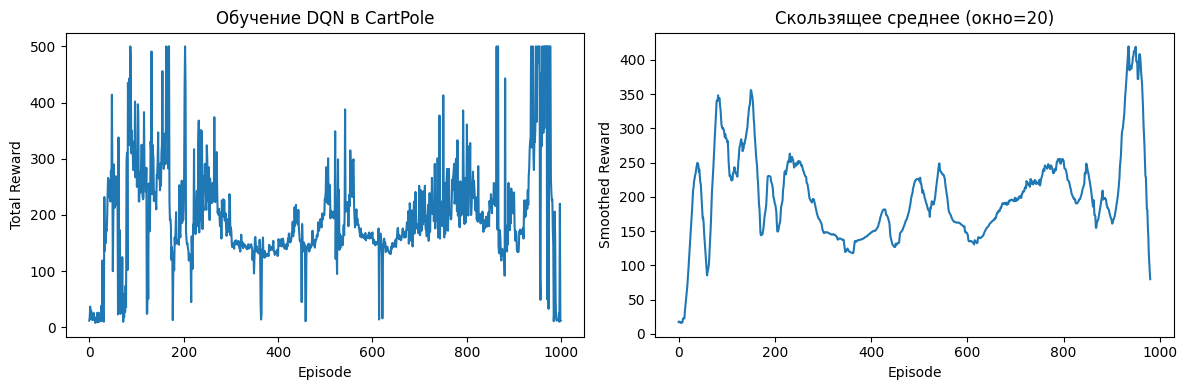

In [6]:
# Визуализация результатов
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rewards_history)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Обучение DQN в CartPole')

# Сглаженная версия
plt.subplot(1, 2, 2)
window_size = 20
smoothed = np.convolve(rewards_history, np.ones(window_size)/window_size, mode='valid')
plt.plot(smoothed)
plt.xlabel('Episode')
plt.ylabel('Smoothed Reward')
plt.title(f'Скользящее среднее (окно={window_size})')

plt.tight_layout()
plt.show()


In [7]:
# Тестирование обученного агента
print("\nТестирование обученного агента...")
test_env = gym.make("CartPole-v1", render_mode="human")
state, info = test_env.reset()
total_reward = 0

for _ in range(500):
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    with torch.no_grad():
        q_values = agent.model(state_tensor)
    action = torch.argmax(q_values).item()

    state, reward, terminated, truncated, info = test_env.step(action)
    total_reward += reward
    test_env.render()

    if terminated or truncated:
        break

print(f"Test reward: {total_reward}")
test_env.close()


Тестирование обученного агента...


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5208:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5208:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5208:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5731:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM default


Test reward: 11.0


## Задачи для самостоятельного решения

In [8]:
# ИСПОЛЬЗУЕМЫЕ БИБЛИОТЕКИ
import gymnasium as gym
import numpy as np
from gymnasium import spaces
import random
import os
from pathlib import Path

<p class="task" id="1"></p>

1\. Создайте окружение `Blackjack-v1`. Сыграйте `N=10000` игр, выбирая действие случайным образом. Посчитайте и выведите на экран долю выигранных игр.

- [ ] Проверено на семинаре

In [9]:
env = gym.make('Blackjack-v1', sab=True)  # sab=True для стандартных правил казино

In [10]:
N = 10000  # количество игр
wins = 0       # счетчик выигрышей
losses = 0     # счетчик проигрышей
draws = 0      # счетчик ничьих
games_played = 0
reward_sum = 0.0

In [11]:
for game in range(N):
    # Сброс среды, начало новой игры
    observation, info = env.reset()
    terminated = False
    truncated = False

    while not (terminated or truncated):
        # В Blackjack: 0 = стоять (stick), 1 = взять карту (hit)
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)

    # В Blackjack: reward = 1.0 (выигрыш), 0.0 (ничья), -1.0 (проигрыш)
    if reward == 1.0:
        wins += 1
    elif reward == -1.0:
        losses += 1
    else:
        draws += 1

    games_played += 1
    reward_sum += reward

    if (game + 1) % 1000 == 0:
        current_win_rate = wins / games_played
        print(f"Игра {game + 1}/{N}: текущий процент выигрышей = {current_win_rate:.2%}")

env.close()

Игра 1000/10000: текущий процент выигрышей = 28.60%
Игра 2000/10000: текущий процент выигрышей = 28.65%
Игра 3000/10000: текущий процент выигрышей = 27.37%
Игра 4000/10000: текущий процент выигрышей = 27.70%
Игра 5000/10000: текущий процент выигрышей = 27.80%
Игра 6000/10000: текущий процент выигрышей = 27.73%
Игра 7000/10000: текущий процент выигрышей = 28.31%
Игра 8000/10000: текущий процент выигрышей = 28.41%
Игра 9000/10000: текущий процент выигрышей = 28.47%
Игра 10000/10000: текущий процент выигрышей = 28.44%


In [12]:
win_rate = wins / N
print(f"Итог после {N} игр:")
print(f"Выиграно игр: {wins}")
print(f"Проиграно игр: {losses}")
print(f"Ничьих: {draws}")
print(f"Доля выигранных игр: {win_rate:.2%}")
print(f"Математическое ожидание выигрыша на игру: {reward_sum / N:.3f}")

Итог после 10000 игр:
Выиграно игр: 2844
Проиграно игр: 6742
Ничьих: 414
Доля выигранных игр: 28.44%
Математическое ожидание выигрыша на игру: -0.390


<p class="task" id="2"></p>

2\. Создайте окружение `Blackjack-v1`. Предложите стратегию, которая позволит, в среднем, выигрывать чаще, чем случайный выбор действия. Реализуйте эту стратегию и сыграйте `N=10000` игр, выбирая действие согласно этой стратегии. Посчитайте и выведите на экран долю выигранных игр.

- [ ] Проверено на семинаре

In [13]:
env = gym.make('Blackjack-v1', sab=True)  # sab=True для стандартных правил казино

In [14]:
# БАЗОВАЯ СТРАТЕГИЯ ДЛЯ BLACKJACK
def basic_strategy_action(player_score, dealer_card, usable_ace):
    """
    Определяет оптимальное действие по базовой стратегии

    Аргументы:
    - player_score: сумма очков игрока (12-21)
    - dealer_card: карта дилера (1-10, где 1 - туз)
    - usable_ace: есть ли у игрока usable ace (1) или нет (0)

    Возвращает:
    - 0: стоять (stick)
    - 1: взять карту (hit)
    """

    # Если у игрока есть usable ace (мягкая рука)
    if usable_ace:
        # Сумма считается как player_score (например, A+6 = 17 мягких)
        if player_score >= 19:  # Мягкие 19-21
            return 0  # Всегда стоять
        elif player_score == 18:
            if dealer_card in [9, 10, 1]:  # Дилер 9, 10 или туз
                return 1  # Брать
            else:
                return 0  # Стоять
        elif player_score == 17:
            if dealer_card in [3, 4, 5, 6]:
                return 1  # Брать (удвоение в реальной стратегии, но у нас нет удвоения)
            else:
                return 1  # Брать
        elif player_score in [15, 16]:
            if dealer_card in [4, 5, 6]:
                return 1  # Брать (удвоение в реальной стратегии)
            else:
                return 1  # Брать
        else:  # Мягкие 13-14
            if dealer_card in [5, 6]:
                return 1  # Брать (удвоение в реальной стратегии)
            else:
                return 1  # Брать

    # Если у игрока нет usable ace (жесткая рука)
    else:
        if player_score >= 17:
            return 0  # Всегда стоять на 17+
        elif player_score in [13, 14, 15, 16]:
            if dealer_card in [2, 3, 4, 5, 6]:
                return 0  # Стоять против слабой карты дилера
            else:
                return 1  # Брать против сильной карты дилера
        elif player_score == 12:
            if dealer_card in [4, 5, 6]:
                return 0  # Стоять
            else:
                return 1  # Брать
        else:  # player_score <= 11
            return 1  # Всегда брать до 11

In [15]:
def test_strategy(strategy_func, N=10000, strategy_name="Стратегия"):
    """Тестирует заданную стратегию на N играх"""
    print(f"\nТестирование стратегии: {strategy_name}")
    print("=" * 50)

    wins = 0
    losses = 0
    draws = 0

    for game in range(N):
        observation, info = env.reset()
        terminated = False
        truncated = False

        while not (terminated or truncated):
            # Распаковывание observation
            player_score, dealer_card, usable_ace = observation

            # Преобразование значения для удобства
            # В Gymnasium: туз дилера = 1, карты 2-10 = 2-10
            # usable_ace: 1 = есть, 0 = нет

            # Выбор действия по стратегии
            action = strategy_func(player_score, dealer_card, usable_ace)

            # Выполнение действие
            observation, reward, terminated, truncated, info = env.step(action)

        # Подсчет результатов
        if reward == 1.0:
            wins += 1
        elif reward == -1.0:
            losses += 1
        else:  # reward == 0.0
            draws += 1

        # Прогресс
        if (game + 1) % 2000 == 0:
            win_rate = wins / (game + 1)
            print(f"Игра {game + 1}/{N}: выигрышей {win_rate:.2%}")

    # Итоговые результаты
    total_games = wins + losses + draws
    win_rate = wins / total_games if total_games > 0 else 0
    loss_rate = losses / total_games if total_games > 0 else 0
    draw_rate = draws / total_games if total_games > 0 else 0

    print("\n" + "="*50)
    print(f"ИТОГО после {N} игр ({strategy_name}):")
    print(f"Выиграно: {wins} ({win_rate:.2%})")
    print(f"Проиграно: {losses} ({loss_rate:.2%})")
    print(f"Ничьих: {draws} ({draw_rate:.2%})")
    print(f"Математическое ожидание: {(wins - losses) / total_games:.3f}")
    print("="*50)

    return win_rate, (wins - losses) / total_games

In [16]:
basic_rate, basic_ev = test_strategy(basic_strategy_action, N, "Базовая стратегия")
env.close()
print(basic_rate, basic_ev)


Тестирование стратегии: Базовая стратегия
Игра 2000/10000: выигрышей 44.10%
Игра 4000/10000: выигрышей 43.25%
Игра 6000/10000: выигрышей 43.20%
Игра 8000/10000: выигрышей 43.48%
Игра 10000/10000: выигрышей 43.00%

ИТОГО после 10000 игр (Базовая стратегия):
Выиграно: 4300 (43.00%)
Проиграно: 4776 (47.76%)
Ничьих: 924 (9.24%)
Математическое ожидание: -0.048
0.43 -0.0476


<p class="task" id="3"></p>

3\. Создайте окружение для игры в крестики-нолики, реализовав интерфейс `gym.Env`. Решение должно удовлетворять следующим условиям:
* для создания пространства состояний используется `spaces.Box`;
* для создания пространства действий используется `spaces.MultiDiscrete`;
* игра прекращается, если:
    - нет возможности сделать ход;
    - игрок пытается отметить уже выбранную ячейку.
* после каждого хода игрок получает награду:
    - 0, если игра не закончена;
    - 1, если игрок выиграл;
    - -1, если игрок проиграл.
* стратегию выбора действия для второго игрока (машины) определите самостоятельно.

Стратегия поведения машины является частью окружения и должна быть реализована внутри него. Сделайте все соответствующие переменные и методы приватными (названия всех переменных начинаются с `__`), подчеркнув, что у пользователя не должно быть к ним доступа извне.

Сыграйте одну игру, выбирая действия случайным образом. Выведите на экран состояние окружения после каждого хода и итоговую награду пользователя за сессию.

- [ ] Проверено на семинаре

In [17]:
class TicTacToeEnv(gym.Env):
    """
    Окружение для игры в крестики-нолики 3x3.
    Игрок (агент) играет крестиками (X), машина играет ноликами (O).
    За один вызов step выполняется ход игрока и, если игра не завершилась, ход машины.
    """

    metadata = {"render_modes": ["ansi"]}

    def __init__(self):
        super().__init__()

        # Пространство действий: строка и столбец
        self.action_space = spaces.MultiDiscrete([3, 3])

        # -1: O (машина), 0: пусто, 1: X (игрок)
        self.observation_space = spaces.Box(
            low=-1, high=1, shape=(3, 3), dtype=np.int8
        )

        # Все внутренние данные и стратегия машины приватные
        self.__board = np.zeros((3, 3), dtype=np.int8)
        self.__game_over = False
        self.__winner = 0
        self.__total_reward = 0.0

    def __str__(self):
        return self.__board_to_string(self.__board)

    def __board_to_string(self, board):
        symbols = {1: "X", -1: "O", 0: "."}
        rows = []
        for i in range(3):
            rows.append(" | ".join(symbols[int(board[i, j])] for j in range(3)))
        return "\n---------\n".join(rows)

    def __get_empty_cells(self, board=None):
        if board is None:
            board = self.__board
        return [tuple(pos) for pos in np.argwhere(board == 0)]

    def __check_winner(self, board=None):
        if board is None:
            board = self.__board

        lines = [board[i, :] for i in range(3)]
        lines += [board[:, j] for j in range(3)]
        lines += [np.diag(board), np.diag(np.fliplr(board))]

        for line in lines:
            line_sum = int(np.sum(line))
            if line_sum == 3:
                return 1
            if line_sum == -3:
                return -1
        return 0

    def __find_winning_move(self, symbol):
        for cell in self.__get_empty_cells():
            test_board = self.__board.copy()
            test_board[cell] = symbol
            if self.__check_winner(test_board) == symbol:
                return cell
        return None

    def __machine_action(self):
        """Защитная стратегия машины: выиграть, заблокировать, иначе случайный ход."""
        empty_cells = self.__get_empty_cells()
        if not empty_cells:
            return None

        # 1. Если машина может выиграть сейчас — выигрывает
        move = self.__find_winning_move(-1)
        if move is not None:
            return move

        # 2. Если игрок может выиграть следующим ходом — блокирует
        move = self.__find_winning_move(1)
        if move is not None:
            return move

        # 3. Иначе делает случайный допустимый ход
        idx = int(self.np_random.integers(len(empty_cells)))
        return empty_cells[idx]

    def __build_info(
        self,
        reason="game_continues",
        invalid_action=False,
        player_action=None,
        machine_action=None,
        board_after_player=None,
        board_after_machine=None,
    ):
        return {
            "winner": int(self.__winner),
            "reason": reason,
            "invalid_action": bool(invalid_action),
            "total_reward": float(self.__total_reward),
            "player_action": player_action,
            "machine_action": machine_action,
            "board_after_player": None if board_after_player is None else board_after_player.copy(),
            "board_after_machine": None if board_after_machine is None else board_after_machine.copy(),
        }

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.__board = np.zeros((3, 3), dtype=np.int8)
        self.__game_over = False
        self.__winner = 0
        self.__total_reward = 0.0
        return self.__board.copy(), self.__build_info(reason="new_game")

    def step(self, action):
        if self.__game_over:
            raise RuntimeError("Игра уже завершена. Вызовите reset().")

        action = np.asarray(action, dtype=np.int64)
        if not self.action_space.contains(action):
            raise ValueError(f"Недопустимое действие {action}. Ожидаются координаты [0..2, 0..2].")

        row, col = map(int, action)
        player_action = (row, col)

        # Попытка поставить X в занятую клетку немедленно завершает игру поражением
        if self.__board[row, col] != 0:
            reward = -1.0
            self.__game_over = True
            self.__winner = -1
            self.__total_reward += reward
            board_now = self.__board.copy()
            info = self.__build_info(
                reason="invalid_action",
                invalid_action=True,
                player_action=player_action,
                board_after_player=board_now,
                board_after_machine=board_now,
            )
            return board_now, reward, True, False, info

        # Ход игрока
        self.__board[row, col] = 1
        board_after_player = self.__board.copy()

        if self.__check_winner() == 1:
            reward = 1.0
            self.__game_over = True
            self.__winner = 1
            self.__total_reward += reward
            info = self.__build_info(
                reason="player_win",
                player_action=player_action,
                board_after_player=board_after_player,
                board_after_machine=board_after_player,
            )
            return self.__board.copy(), reward, True, False, info

        if not self.__get_empty_cells():
            self.__game_over = True
            self.__winner = 0
            info = self.__build_info(
                reason="draw",
                player_action=player_action,
                board_after_player=board_after_player,
                board_after_machine=board_after_player,
            )
            return self.__board.copy(), 0.0, True, False, info

        # Ход машины
        machine_action = self.__machine_action()
        self.__board[machine_action] = -1
        board_after_machine = self.__board.copy()

        if self.__check_winner() == -1:
            reward = -1.0
            self.__game_over = True
            self.__winner = -1
            self.__total_reward += reward
            info = self.__build_info(
                reason="machine_win",
                player_action=player_action,
                machine_action=machine_action,
                board_after_player=board_after_player,
                board_after_machine=board_after_machine,
            )
            return self.__board.copy(), reward, True, False, info

        if not self.__get_empty_cells():
            self.__game_over = True
            self.__winner = 0
            info = self.__build_info(
                reason="draw",
                player_action=player_action,
                machine_action=machine_action,
                board_after_player=board_after_player,
                board_after_machine=board_after_machine,
            )
            return self.__board.copy(), 0.0, True, False, info

        info = self.__build_info(
            reason="game_continues",
            player_action=player_action,
            machine_action=machine_action,
            board_after_player=board_after_player,
            board_after_machine=board_after_machine,
        )
        return self.__board.copy(), 0.0, False, False, info

    def render(self):
        return self.__board_to_string(self.__board)

In [18]:
def board_to_string(board):
    symbols = {1: "X", -1: "O", 0: "."}
    rows = [" | ".join(symbols[int(board[i, j])] for j in range(3)) for i in range(3)]
    return "\n---------\n".join(rows)


def play_random_game(seed=42):
    """Сыграть одну игру со случайными действиями и показать поле после каждого реального хода."""
    print("=" * 50)
    print("НАЧАЛО НОВОЙ ИГРЫ В КРЕСТИКИ-НОЛИКИ")
    print("Игрок (X) делает случайные действия, машина (O) играет защитно")
    print("=" * 50)

    env = TicTacToeEnv()
    observation, info = env.reset(seed=seed)
    env.action_space.seed(seed)

    print("Начальное состояние:")
    print(board_to_string(observation))

    terminated = False
    truncated = False
    move_number = 1

    while not (terminated or truncated):
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)

        print(f"\nХод {move_number}. Игрок X -> {tuple(map(int, action))}")
        print(board_to_string(info["board_after_player"]))
        move_number += 1

        if info["machine_action"] is not None:
            print(f"\nХод {move_number}. Машина O -> {info['machine_action']}")
            print(board_to_string(info["board_after_machine"]))
            move_number += 1

        print(f"Награда за действие игрока: {reward:g}")

    print("\n" + "=" * 50)
    print("ИГРА ЗАВЕРШЕНА")
    print(f"Причина: {info['reason']}")
    print(f"Итоговая награда пользователя: {info['total_reward']:g}")
    print("=" * 50)
    env.close()
    return info["total_reward"]

In [19]:
def test_multiple_games(num_games=100, seed=42):
    """Небольшая проверка статистики случайных действий."""
    results = {"win": 0, "lose": 0, "draw": 0, "invalid": 0}

    for game in range(num_games):
        env = TicTacToeEnv()
        observation, info = env.reset(seed=seed + game)
        env.action_space.seed(seed + game)
        terminated = truncated = False

        while not (terminated or truncated):
            action = env.action_space.sample()
            observation, reward, terminated, truncated, info = env.step(action)

        # Invalid проверяется раньше winner, потому что invalid_action также означает поражение
        if info["invalid_action"]:
            results["invalid"] += 1
        elif info["winner"] == 1:
            results["win"] += 1
        elif info["winner"] == -1:
            results["lose"] += 1
        else:
            results["draw"] += 1
        env.close()

    print(f"\nСтатистика за {num_games} случайных игр:")
    print(f"Побед: {results['win']}")
    print(f"Поражений от машины: {results['lose']}")
    print(f"Ничьих: {results['draw']}")
    print(f"Недопустимых ходов: {results['invalid']}")
    return results

In [20]:
final_reward = play_random_game(seed=42)

НАЧАЛО НОВОЙ ИГРЫ В КРЕСТИКИ-НОЛИКИ
Игрок (X) делает случайные действия, машина (O) играет защитно
Начальное состояние:
. | . | .
---------
. | . | .
---------
. | . | .

Ход 1. Игрок X -> (2, 1)
. | . | .
---------
. | . | .
---------
. | X | .

Ход 2. Машина O -> (np.int64(0), np.int64(0))
O | . | .
---------
. | . | .
---------
. | X | .
Награда за действие игрока: 0

Ход 3. Игрок X -> (2, 2)
O | . | .
---------
. | . | .
---------
. | X | X

Ход 4. Машина O -> (np.int64(2), np.int64(0))
O | . | .
---------
. | . | .
---------
O | X | X
Награда за действие игрока: 0

Ход 5. Игрок X -> (0, 2)
O | . | X
---------
. | . | .
---------
O | X | X

Ход 6. Машина O -> (np.int64(1), np.int64(0))
O | . | X
---------
O | . | .
---------
O | X | X
Награда за действие игрока: -1

ИГРА ЗАВЕРШЕНА
Причина: machine_win
Итоговая награда пользователя: -1


In [21]:
test_multiple_games(100, seed=42)


Статистика за 100 случайных игр:
Побед: 0
Поражений от машины: 23
Ничьих: 0
Недопустимых ходов: 77


{'win': 0, 'lose': 23, 'draw': 0, 'invalid': 77}

<p class="task" id="4"></p>

4\. Предложите стратегию (в виде алгоритма без использования методов машинного обучения), которая позволит, в среднем, выигрывать в крестики-нолики чаще, чем случайный выбор действия. Реализуйте эту стратегию и сыграйте игру, выбирая действия согласно этой стратегии. Выведите на экран состояние окружения после каждого хода и итоговую награду пользователя за сессию.

- [ ] Проверено на семинаре

In [23]:
class OptimalTicTacToeStrategy:
    """
    Эвристическая стратегия без машинного обучения.

    Приоритет действий:
    1. выиграть сейчас;
    2. заблокировать немедленный выигрыш машины;
    3. создать вилку;
    4. заблокировать вилку машины;
    5. занять центр;
    6. занять противоположный угол;
    7. занять свободный угол;
    8. занять свободную сторону.
    """

    def _empty_cells(self, board):
        return [tuple(pos) for pos in np.argwhere(board == 0)]

    def _winner(self, board):
        lines = [board[i, :] for i in range(3)]
        lines += [board[:, j] for j in range(3)]
        lines += [np.diag(board), np.diag(np.fliplr(board))]
        for line in lines:
            s = int(np.sum(line))
            if s == 3:
                return 1
            if s == -3:
                return -1
        return 0

    def _winning_move(self, board, symbol):
        for move in self._empty_cells(board):
            test_board = board.copy()
            test_board[move] = symbol
            if self._winner(test_board) == symbol:
                return move
        return None

    def _fork_moves(self, board, symbol):
        forks = []
        for move in self._empty_cells(board):
            test_board = board.copy()
            test_board[move] = symbol
            winning_replies = 0
            for next_move in self._empty_cells(test_board):
                next_board = test_board.copy()
                next_board[next_move] = symbol
                if self._winner(next_board) == symbol:
                    winning_replies += 1
            if winning_replies >= 2:
                forks.append(move)
        return forks

    def select_action(self, board):
        board = np.asarray(board)

        # 1. Немедленная победа
        move = self._winning_move(board, 1)
        if move is not None:
            return move

        # 2. Блок немедленной победы O
        move = self._winning_move(board, -1)
        if move is not None:
            return move

        # 3. Создание вилки
        my_forks = self._fork_moves(board, 1)
        if my_forks:
            return my_forks[0]

        # 4. Блокировка вилки O
        opponent_forks = self._fork_moves(board, -1)
        if len(opponent_forks) == 1:
            return opponent_forks[0]
        if len(opponent_forks) > 1:
            # При нескольких вилках сторона обычно заставляет O отвечать на угрозу
            for move in [(0, 1), (1, 0), (1, 2), (2, 1)]:
                if board[move] == 0:
                    return move

        # 5. Центр
        if board[1, 1] == 0:
            return (1, 1)

        # 6. Противоположный угол
        pairs = [
            ((0, 0), (2, 2)), ((0, 2), (2, 0)),
            ((2, 0), (0, 2)), ((2, 2), (0, 0)),
        ]
        for corner, opposite in pairs:
            if board[opposite] == -1 and board[corner] == 0:
                return corner

        # 7. Свободный угол
        for move in [(0, 0), (0, 2), (2, 0), (2, 2)]:
            if board[move] == 0:
                return move

        # 8. Свободная сторона
        for move in [(0, 1), (1, 0), (1, 2), (2, 1)]:
            if board[move] == 0:
                return move

        raise RuntimeError("Свободных клеток не осталось")

In [24]:
def play_with_optimal_strategy(seed=7):
    """Сыграть одну игру с выбранной стратегией и показать состояние после каждого хода."""
    env = TicTacToeEnv()
    strategy = OptimalTicTacToeStrategy()
    observation, info = env.reset(seed=seed)

    print("=" * 60)
    print("ИГРОК X: ЭВРИСТИЧЕСКАЯ СТРАТЕГИЯ  vs  МАШИНА O: ЗАЩИТНАЯ СТРАТЕГИЯ")
    print("=" * 60)
    print("Начальное состояние:")
    print(board_to_string(observation))

    terminated = truncated = False
    move_number = 1

    while not (terminated or truncated):
        action = strategy.select_action(observation)
        observation, reward, terminated, truncated, info = env.step(action)

        print(f"\nХод {move_number}. Игрок X -> {action}")
        print(board_to_string(info["board_after_player"]))
        move_number += 1

        if info["machine_action"] is not None:
            print(f"\nХод {move_number}. Машина O -> {info['machine_action']}")
            print(board_to_string(info["board_after_machine"]))
            move_number += 1

        print(f"Награда за действие игрока: {reward:g}")

    print("\n" + "=" * 60)
    print(f"Игра завершена: {info['reason']}")
    print(f"Итоговая награда пользователя: {info['total_reward']:g}")
    print("=" * 60)
    env.close()
    return info["total_reward"]

In [25]:
# СРАВНЕНИЕ СЛУЧАЙНОЙ И ПРЕДЛОЖЕННОЙ СТРАТЕГИЙ
def compare_strategies(num_games=1000, seed=42):
    strategy = OptimalTicTacToeStrategy()
    random_rng = np.random.default_rng(seed)

    random_results = {"win": 0, "lose": 0, "draw": 0}
    smart_results = {"win": 0, "lose": 0, "draw": 0}

    for game in range(num_games):
        game_seed = seed + game

        # Случайная стратегия: случайный выбор только из допустимых клеток
        env_random = TicTacToeEnv()
        obs, _ = env_random.reset(seed=game_seed)
        terminated = truncated = False
        while not (terminated or truncated):
            legal_moves = [tuple(pos) for pos in np.argwhere(obs == 0)]
            action = legal_moves[int(random_rng.integers(len(legal_moves)))]
            obs, reward, terminated, truncated, info = env_random.step(action)
        if info["winner"] == 1:
            random_results["win"] += 1
        elif info["winner"] == -1:
            random_results["lose"] += 1
        else:
            random_results["draw"] += 1
        env_random.close()

        # Предложенная стратегия
        env_smart = TicTacToeEnv()
        obs, _ = env_smart.reset(seed=game_seed)
        terminated = truncated = False
        while not (terminated or truncated):
            action = strategy.select_action(obs)
            obs, reward, terminated, truncated, info = env_smart.step(action)
        if info["winner"] == 1:
            smart_results["win"] += 1
        elif info["winner"] == -1:
            smart_results["lose"] += 1
        else:
            smart_results["draw"] += 1
        env_smart.close()

    random_win_rate = random_results["win"] / num_games
    smart_win_rate = smart_results["win"] / num_games

    print(f"Сравнение на {num_games} играх:")
    print("\nСлучайная стратегия:")
    print(f"  Побед: {random_results['win']} ({random_win_rate:.2%})")
    print(f"  Поражений: {random_results['lose']} ({random_results['lose']/num_games:.2%})")
    print(f"  Ничьих: {random_results['draw']} ({random_results['draw']/num_games:.2%})")

    print("\nПредложенная стратегия:")
    print(f"  Побед: {smart_results['win']} ({smart_win_rate:.2%})")
    print(f"  Поражений: {smart_results['lose']} ({smart_results['lose']/num_games:.2%})")
    print(f"  Ничьих: {smart_results['draw']} ({smart_results['draw']/num_games:.2%})")

    print(f"\nИзменение доли побед: {(smart_win_rate - random_win_rate):+.2%}")
    if smart_win_rate > random_win_rate:
        print("✓ Предложенная стратегия выигрывает чаще случайной.")
    else:
        print("✗ На этой выборке улучшения доли побед нет.")

    return random_results, smart_results

In [26]:
print("ДЕМОНСТРАЦИЯ ПРЕДЛОЖЕННОЙ СТРАТЕГИИ")
final_reward = play_with_optimal_strategy(seed=7)

print("\n" + "=" * 60)
compare_strategies(num_games=1000, seed=42)

ДЕМОНСТРАЦИЯ ПРЕДЛОЖЕННОЙ СТРАТЕГИИ
ИГРОК X: ЭВРИСТИЧЕСКАЯ СТРАТЕГИЯ  vs  МАШИНА O: ЗАЩИТНАЯ СТРАТЕГИЯ
Начальное состояние:
. | . | .
---------
. | . | .
---------
. | . | .

Ход 1. Игрок X -> (1, 1)
. | . | .
---------
. | X | .
---------
. | . | .

Ход 2. Машина O -> (np.int64(2), np.int64(2))
. | . | .
---------
. | X | .
---------
. | . | O
Награда за действие игрока: 0

Ход 3. Игрок X -> (0, 0)
X | . | .
---------
. | X | .
---------
. | . | O

Ход 4. Машина O -> (np.int64(1), np.int64(2))
X | . | .
---------
. | X | O
---------
. | . | O
Награда за действие игрока: 0

Ход 5. Игрок X -> (np.int64(0), np.int64(2))
X | . | X
---------
. | X | O
---------
. | . | O

Ход 6. Машина O -> (np.int64(0), np.int64(1))
X | O | X
---------
. | X | O
---------
. | . | O
Награда за действие игрока: 0

Ход 7. Игрок X -> (np.int64(2), np.int64(0))
X | O | X
---------
. | X | O
---------
X | . | O
Награда за действие игрока: 1

Игра завершена: player_win
Итоговая награда пользователя: 1

Сравнение

({'win': 55, 'lose': 703, 'draw': 242}, {'win': 832, 'lose': 0, 'draw': 168})

<p class="task" id="5"></p>

5\. Создайте окружение `MountainCar-v0`. Проиграйте 10 эпизодов и сохраните на диск файл с записью каждого пятого эпизода. Для записи видео воспользуйтесь обёрткой `RecordVideo`. Вставьте скриншот, на котором видно, что файлы были созданы.

- [ ] Проверено на семинаре

Видео будут сохранены в директорию: /home/crazy/work/labs/mountaincar_videos
Эпизод  1: шагов=200, награда=-200.00
Эпизод  2: шагов=200, награда=-200.00
Эпизод  3: шагов=200, награда=-200.00
Эпизод  4: шагов=200, награда=-200.00


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5208:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5208:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5208:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5731:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM default


Эпизод  5: шагов=200, награда=-200.00 <- записывается
Эпизод  6: шагов=200, награда=-200.00
Эпизод  7: шагов=200, награда=-200.00
Эпизод  8: шагов=200, награда=-200.00
Эпизод  9: шагов=200, награда=-200.00
Эпизод 10: шагов=200, награда=-200.00 <- записывается

Созданные видеофайлы:
  mountaincar-episode-4.mp4 (32.4 KB)
  mountaincar-episode-9.mp4 (39.6 KB)

✓ Записаны 5-й и 10-й эпизоды.


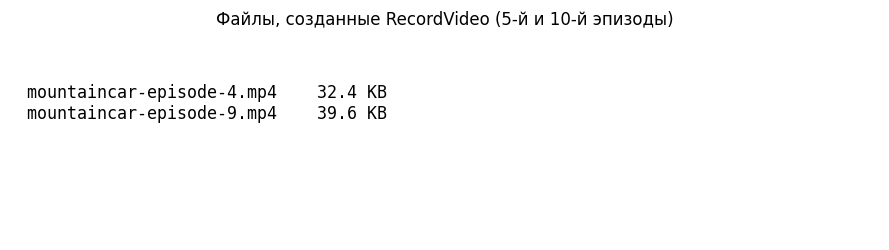

In [29]:
# Создание директории для сохранения видео
import shutil
import matplotlib.pyplot as plt

video_dir = Path("mountaincar_videos")
if video_dir.exists():
    shutil.rmtree(video_dir)
video_dir.mkdir(parents=True, exist_ok=True)

print(f"Видео будут сохранены в директорию: {video_dir.resolve()}")

# RecordVideo передает в episode_trigger внутренний episode_id, начинающийся с 0.
# Поэтому episode_id 4 и 9 соответствуют человеческим эпизодам 5 и 10.
env = gym.make("MountainCar-v0", render_mode="rgb_array")
env = gym.wrappers.RecordVideo(
    env,
    video_folder=str(video_dir),
    episode_trigger=lambda episode_id: (episode_id + 1) % 5 == 0,
    name_prefix="mountaincar",
)

num_episodes = 10
for episode in range(num_episodes):
    observation, info = env.reset(seed=42 + episode)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated):
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        step_count += 1

    mark = " <- записывается" if (episode + 1) % 5 == 0 else ""
    print(
        f"Эпизод {episode + 1:2d}: шагов={step_count:3d}, "
        f"награда={total_reward:7.2f}{mark}"
    )

env.close()

# Проверка, что RecordVideo создал два mp4-файла
video_files = sorted(video_dir.glob("*.mp4"))
print("\nСозданные видеофайлы:")
for file_path in video_files:
    print(f"  {file_path.name} ({file_path.stat().st_size / 1024:.1f} KB)")

assert len(video_files) == 2, f"Ожидалось 2 видеофайла, найдено: {len(video_files)}"

# Внутренние id в названиях файлов будут 4 и 9 — это именно 5-й и 10-й эпизоды.
print("\n✓ Записаны 5-й и 10-й эпизоды.")

# Визуальное подтверждение созданных файлов прямо в notebook
file_lines = [
    f"{p.name}    {p.stat().st_size / 1024:.1f} KB"
    for p in video_files
]
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.axis("off")
ax.set_title("Файлы, созданные RecordVideo (5-й и 10-й эпизоды)")
ax.text(
    0.02, 0.75,
    "\n".join(file_lines),
    family="monospace",
    fontsize=12,
    va="top",
)
plt.tight_layout()
plt.show()

In [28]:
pip install moviepy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 1.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.5/29.5 MB 3.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 2.8 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pillow
    Found existing installation: pillow 12.1.1
    Uninstalling pillow-12.1.1:
      Successfully uninstalled pillow-12.1.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
perch-hoplite 1.0.1 requires absl-py<2.0.0,>=1.4.0, but you have absl-py 2.4.0 which is incompatible.
perch-hoplite 1.0.1 requires kagglehub<0.4,>=0.3, but you have kagglehub 1.0.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


После выполнения ячейки выше notebook автоматически показывает визуальный список файлов, реально созданных `RecordVideo`. Внутренние `episode_id=4` и `episode_id=9` соответствуют 5-му и 10-му эпизодам соответственно.

## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ